## 0. Introduction

The purpose of this notebook is to explore expectation with reference to chapter 3 from *All of Statistics* (Wasserman, 2004).

## 1. Expectation of a Random Variable

The **expected value**, or **mean**, or **first moment**, of $X$ is defined to be

$$
\mathbb{E}[X] = \int x \, dF(x) = 
\begin{cases}
\sum_x x f(x), & \text{if } X \text{ is discrete} \\
\int x f(x) \, dx, & \text{if } X \text{ is continuous}
\end{cases}
$$

assuming that the sum (or integral) is well defined. We use the following notation to denote the expected value of $X$:

$$ \mathbb{E}[X] = \mathbb{E}X = \int x \, dF(x) = \mu = \mu_X. $$

The expectation is a one-number summary of the distribution. Think of $\mathbb{E}[X]$ as the average $\sum_{i=1}^n X_i/n$ of a large number of IID draws $X_1, \ldots, X_n$. The fact that $\mathbb{E}[X] \approx \sum_{i=1}^n X_i/n$ is actually more than a heuristic; it is a theorem called the **law of large numbers**.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

In [2]:
# Generate random variable
n = 1000
x = ss.norm.rvs(size=n, random_state=42)

In [3]:
# Calculate mean
mu_x = np.sum(x) / n

# Print results
print(f"Mean of x (manual calculation): {mu_x:.3f}")
print(f"Mean of x (using numpy): {np.mean(x):.3f}")

Mean of x (manual calculation): 0.019
Mean of x (using numpy): 0.019


## 2. Variance and Covariance

The variance measures the "spread" of a distribution. Let $X$ be a random variable with mean $\mu$. The **variance** of $X$ - denoted by $\sigma^2$ or $\sigma_X^2$ or $\mathbb{V}(X)$ or $\mathbb{V}X$ - is defined by

$$ \sigma^2 = \mathbb{E}[(X - \mu)^2] = \int (x - \mu)^2 \, dF(x) $$

assuming this expectation exists. The **standard deviation** is $\text{sd}(X) = \sqrt{\mathbb{V}(X)}$ and is also denoted by $\sigma$ and $\sigma_X$.

Let $X$ and $Y$ be random variables with means $\mu_X$ and $\mu_Y$ and standard deviations $\sigma_X$ and $\sigma_Y$. Define the **covariance** between $X$ and $Y$ by

$$ \text{Cov}(X, Y) = \mathbb{E}\left[(X - \mu_X)(Y - \mu_Y)\right] $$

and the **correlation** by 

$$ \rho = \rho_{X,Y} = \rho(X, Y) = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}. $$



In [4]:
# Calculate variance
var_x = np.sum((x - mu_x)**2) / n

# Print results
print(f"Variance of x (manual calculation): {var_x:.3f}")
print(f"Variance of x (using numpy): {np.var(x, ddof=0):.3f}")

Variance of x (manual calculation): 0.958
Variance of x (using numpy): 0.958


In [5]:
# Calculate standard deviation
sd_x = np.sqrt(var_x)

# Print results
print(f"Standard deviation of x (manual calculation): {sd_x:.3f}")
print(f"Standard deviation of x (using numpy): {np.std(x, ddof=0):.3f}")

Standard deviation of x (manual calculation): 0.979
Standard deviation of x (using numpy): 0.979


In [6]:
# Generate a second random variable
y = 0.8 * x + ss.norm.rvs(scale=0.6, size=n, random_state=34)
mu_y = np.sum(y) / n
var_y = np.sum((y - mu_y)**2) / n
sd_y = np.sqrt(var_y)

# Print results
print(f"Mean of y: {mu_y:.3f}")
print(f"Variance of y: {var_y:.3f}")
print(f"Standard deviation of y: {sd_y:.3f}")

Mean of y: -0.009
Variance of y: 0.946
Standard deviation of y: 0.973


In [7]:
# Calculate covariance
cov_xy = np.sum((x - mu_x) * (y - mu_y)) / n

# Print results
print(f"Covariance of x and y (manual calculation): {cov_xy:.3f}")
print(f"Covariance of x and y (using numpy): {np.cov(x, y, ddof=0)[0,1]:.3f}")

Covariance of x and y (manual calculation): 0.764
Covariance of x and y (using numpy): 0.764


In [8]:
# Covariance matrix
cov_matrix = np.cov(x, y, ddof=0)

# Print results
print(f"Covariance matrix: \n{np.round(cov_matrix, 3)}")

Covariance matrix: 
[[0.958 0.764]
 [0.764 0.946]]


In [9]:
# Calculate correlation
corr_xy = cov_xy / (sd_x * sd_y)

# Print results
print(f"Correlation of x and y (manual calculation): {corr_xy:.3f}")
print(f"Correlation of x and y (using numpy): {np.corrcoef(x, y)[0,1]:.3f}")

Correlation of x and y (manual calculation): 0.803
Correlation of x and y (using numpy): 0.803


In [10]:
# Correlation matrix
corr_matrix = np.corrcoef(x, y)

# Print results
print(f"Correlation matrix: \n{np.round(corr_matrix, 3)}")

Correlation matrix: 
[[1.    0.803]
 [0.803 1.   ]]


## 3. Taylor Series

The Taylor series (sometimes called expansion) of a function is an infinite sum of terms that are expressed in terms of the function's derivatives at a single point. It is a very important concept in calculus so its worth pausing for a moment to review here. A function $f(x)$ may be expanded about a point $a$ (provided the derivatives are smooth and exist)

$$ f(x) = f(a) + \frac{df}{dx} (a) (x - a) + \frac{d^2f}{dx^2} (a) \frac{(x - a)^2}{2!} + \frac{d^3f}{dx^3} (a) \frac{(x - a)^3}{3!} + \cdots + \frac{d^nf}{dx^n} (a) \frac{(x - a)^n}{n!} + \cdots $$

If $a = 0$, the expansion is known as a Maclaurin series.

Let's consider an example where $f(x) = \sin(x)$ and $a = 0$. The Taylor expansion is given by,

$$
\begin{aligned}
\sin(x) &= \sin(0) + \cos(0)\,x - \frac{\sin(0)}{2!}x^2 - \frac{\cos(0)}{3!}x^3
          + \frac{\sin(0)}{4!}x^4 + \frac{\cos(0)}{5!}x^5 + \cdots \\[6pt]
        &= x - \frac{x^3}{3!} + \frac{x^5}{5!} + \cdots
\end{aligned}
$$

We can see that there is a pattern here.

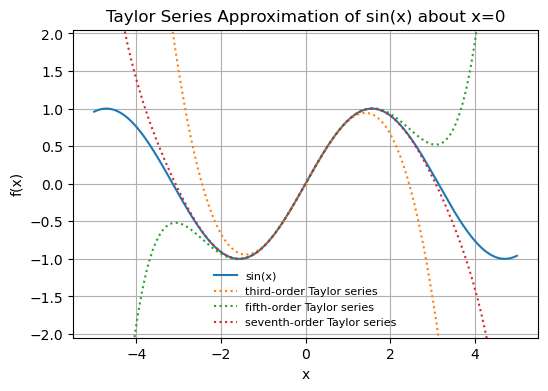

In [11]:
X = np.linspace(-5, 5, 1000)
y = np.sin(X)
yT3 = X - X**3 / math.factorial(3)
yT5 = X - X**3 / math.factorial(3) + X**5 / math.factorial(5)
yT7 = X - X**3 / math.factorial(3) + X**5 / math.factorial(5) - X**7 / math.factorial(7)

plt.figure(figsize=(6,4))
plt.plot(X, y, label='sin(x)')
plt.plot(X, yT3, linestyle='dotted', label='third-order Taylor series')
plt.plot(X, yT5, linestyle='dotted', label='fifth-order Taylor series')
plt.plot(X, yT7, linestyle='dotted', label='seventh-order Taylor series')
plt.ylim(-2.05, 2.05)
plt.title('Taylor Series Approximation of sin(x) about x=0')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend(fontsize=8, framealpha=0)
plt.show()

The Maclaurin series of $f(x) = e^x$ is very easy to derive since every derivative equals $e^x$ and $e^0 = 1$.

$$ e^x = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \frac{x^4}{4!} + \frac{x^5}{5!} + \cdots $$

Euler's formula, named after Leonhard Euler, is a mathematical formula in complex analysis that establishes the fundamental relationship between the trigonometric functions and the complex exponential function. Let $i = \sqrt{-1}$, we can write

$$
\begin{aligned}
e^{ix} &= 1 + ix + \frac{(ix)^2}{2!} + \frac{(ix)^3}{3!} + \frac{(ix)^4}{4!} + \frac{(ix)^5}{5!} + \cdots \\[6pt]
       &= 1  + ix - \frac{x^2}{2!} - i \frac{x^3}{3!} + \frac{x^4}{4!} + i \frac{x^5}{5!} + \cdots \\[6pt]
       &= \left( 1 - \frac{x^2}{2!} + \frac{x^4}{4!} + \cdots \right) + i \left( x - \frac{x^3}{3!} + \frac{x^5}{5!} + \cdots \right)
\end{aligned}
$$

Notice in the second line of the equation above that all of the even powers of $x$ do not have an $i$ but all of the odd powers of $x$ do have an $i$. If we group the even powers together and all the odd powers together (the third line), then you should hopefully recognise that these terms are the Taylor series of $\cos(x)$ and $i \sin(x)$, respectively. This is Euler's formula, given by

$$ e^{ix} = \cos(x) + i \sin(x). $$

## 4. Convergence of Random Variables

The to main types of convergence are defined as follows. 

Let $X_1, X_2, \ldots$ be a sequence of random variables and let $X$ be another random variable. Let $F_n$ denote the CDF of $X_n$ and let $F$ denote the CDF of $X$.

1. $X_n$ **converges to $X$ in probability**, written $X_n \xrightarrow{P} X$, if, for every $\epsilon > 0$,
   $$ \mathbb{P}(|X_n - X| > \epsilon) \to 0 $$
   as n $\to \infty$.
   
2. $X_n$ **converges to $X$ in distribution**, written $X_n \xrightarrow{d} X$, if
   $$ \lim_{n \to \infty} F_n(t) = F(t) $$
   at all $t$ for which $F$ is continuous.